In [2]:
from misc_utils import hadamard_transform
import numpy as np
from spin_lattices import KagomeLattice
from spin_systems import (
    heisenberg,
    heisenberg_transversal_field,
    spin_system,
    no_symmetries_basis,
    LatticeExpr,
)
from spin_lattices import KagomeLattice, SquareLattice, TriangularLattice

# from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
from hadamard_learning import evaluate_hadamard_learning_test_set
from tqdm.auto import tqdm
import pandas as pd
import seaborn as sns

In [3]:
def overlap(u, v):
    return u @ v / np.linalg.norm(u) / np.linalg.norm(v)

In [3]:
# lattice = KagomeLattice(2, 4)
# output = []
# random_wavefunction = np.random.uniform(-1, 1, 2 ** lattice.number_spins)
# for J2 in [0.3, 0.5, 0.8, 1]:
#     for h in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#         expr1 = LatticeExpr(
#             lattice,
#             edge_str="2 (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁",
#             edge_params={1: 1, 2: J2},
#             node_str=f"{h} σˣ₀" if h != 0 else None,
#         )
#         expr2 = LatticeExpr(
#             lattice,
#             edge_str=(
#                 "0.5 (σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)(σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀)(σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁) "
#                 "+ 0.25 (σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)σᶻ₀ σᶻ₁(σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)"
#             ),
#             node_str=f"{h * 0.5} (σˣ₀ + σᶻ₀)σˣ₀ (σˣ₀ + σᶻ₀)" if h != 0 else None,
#             edge_params={1: 1, 2: J2},
#         )

#         system1 = spin_system(expr1, no_symmetries_basis(hamming_weight=None))
#         system2 = spin_system(expr2, no_symmetries_basis(hamming_weight=None))
#         output.append(
#             {
#                 "J2": J2,
#                 "h": h,
#                 "overlap": overlap(
#                     system1.hamiltonian @ random_wavefunction,
#                     system2.hamiltonian @ random_wavefunction,
#                 ),
#             }
#         )

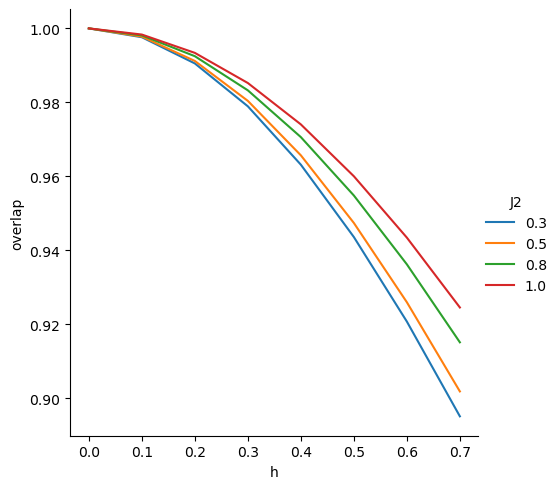

In [4]:
# sns.relplot(pd.DataFrame(output).astype({"J2": str}), x="h", y="overlap", hue="J2", kind="line")

In [9]:
lattice = KagomeLattice(2, 4)
outputs = []
sample_power = 2

for h in tqdm(np.linspace(1.5, 2, 11)):
    for J2 in [1]:
        system = spin_system(
            LatticeExpr(
                lattice,
                edge_str=f"{2 - h} (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁",
                edge_params={1: 1, 2: J2},
            ),
            no_symmetries_basis(hamming_weight=None, spin_inversion=None),
        )
        wavefunction = system.ground_state
        transformed_wavefunction = hadamard_transform(wavefunction)
        outputs.append(
            evaluate_hadamard_learning_test_set(
                wavefunction=wavefunction,
                basis=system.basis,
                sample_power=sample_power,
                test_size=50000,
                eps_train=1e-2,
            )
            | {
                "h": h,
                "lattice": "kagome2x4",
                "overlap_with_transformed": transformed_wavefunction
                @ wavefunction
                / np.linalg.norm(wavefunction)
                / np.linalg.norm(transformed_wavefunction),
                "J2": J2,
                "ground_energy": system.ground_energy,
            }
        )

  0%|          | 0/11 [00:00<?, ?it/s]

2024-10-03 13:58:24.055 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-10-03 13:58:24.068 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-10-03 13:58:24.128 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-10-03 13:58:24.291 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-10-03 13:58:24.397 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-10-03 13:58:24.475 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-10-03 13:58:24.543 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-10-03 13:58:24.608 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-10-03 13:58:24.683 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-10-03 13:58:24.755 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-1

In [15]:
def get_system(h, J2, lattice):
    return spin_system(
        LatticeExpr(
            lattice,
            edge_str=f"{2 - h} (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁",
            edge_params={1: 1, 2: J2},
        ),
        no_symmetries_basis(hamming_weight=None, spin_inversion=None),
    )

In [7]:
system = spin_system(
    LatticeExpr(
        KagomeLattice(2, 4),
        edge_str=f"{2 - h} (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁",
        edge_params={1: 1, 2: 0.5},
    #    node_str="0.9 σˣ₀",
    ),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
system.get_eigenstates(2)
# ground_state = system.ground_state
# transformed_wavefunction = hadamard_transform(ground_state)

# transformed_wavefunction @ ground_state / np.linalg.norm(ground_state) / np.linalg.norm(
#     transformed_wavefunction
# )

2024-10-03 13:39:47.174 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2024-10-03 13:48:43.631 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -32.3401930431


(array([-32.34019304, -32.34019304]),
 array([[ 1.69752195e-17, -9.06148475e-17],
        [-1.34503089e-17,  5.70280586e-17],
        [-4.45513389e-17,  7.85834525e-17],
        ...,
        [ 4.23593493e-17, -2.84807806e-17],
        [-1.99957522e-17, -2.94665210e-17],
        [ 4.85773940e-17,  5.99118675e-17]]))

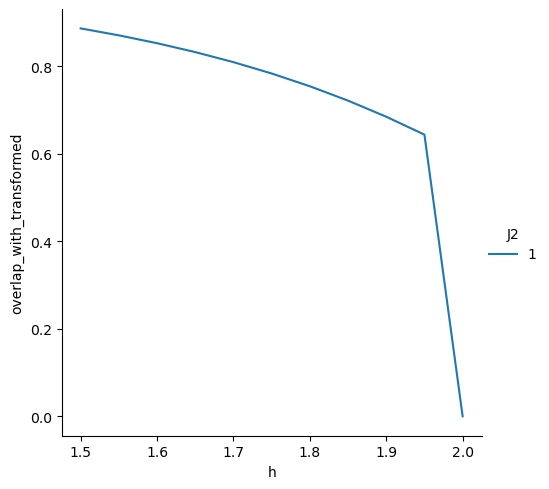

In [10]:
sns.relplot(
    pd.DataFrame(outputs).astype({"J2": str}),
    x="h",
    y="overlap_with_transformed",
    hue="J2",
    kind="line",
)

In [12]:
pd.DataFrame(outputs)

,sample_size,eps_train,sample_power,test_size,accuracy_test,sign_overlap_test,h,lattice,overlap_with_transformed,J2,ground_energy
0,24209,0.01,2,50000,0.66074,0.994050,1.50,kagome2x4,0.886003,1,-22.119472
1,24209,0.01,2,50000,0.66466,0.996088,1.55,kagome2x4,0.870134,1,-21.466862
2,24209,0.01,2,50000,0.66892,0.996235,1.60,kagome2x4,0.852178,1,-20.820664
3,24208,0.01,2,50000,0.67048,0.996078,1.65,kagome2x4,0.831871,1,-20.181621
4,24208,0.01,2,50000,0.67323,0.997082,1.70,kagome2x4,0.808920,1,-19.550584
5,24208,0.01,2,50000,0.67386,0.996443,1.75,kagome2x4,0.783011,1,-18.928538
6,24208,0.01,2,50000,0.67416,0.997482,1.80,kagome2x4,0.753814,1,-18.316622
7,24207,0.01,2,50000,0.67028,0.996173,1.85,kagome2x4,0.720995,1,-17.716152
8,24191,0.01,2,50000,0.67580,0.997132,1.90,kagome2x4,0.684242,1,-17.128660
9,24123,0.01,2,50000,0.66914,0.997422,1.95,kagome2x4,0.643292,1,-16.555922


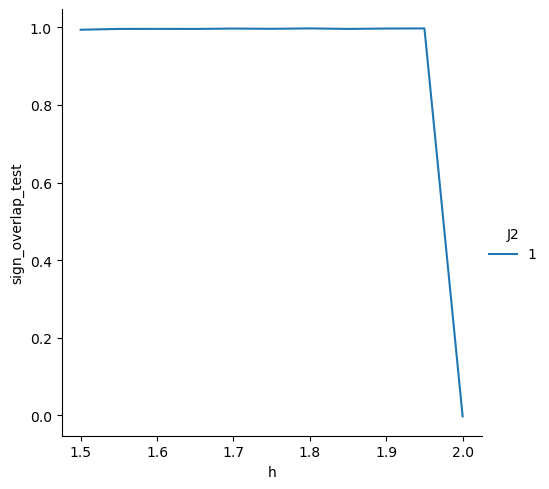

In [11]:
sns.relplot(
    pd.DataFrame(outputs).astype({"J2": str}),
    x="h",
    y="sign_overlap_test",
    hue="J2",
    kind="line",
)

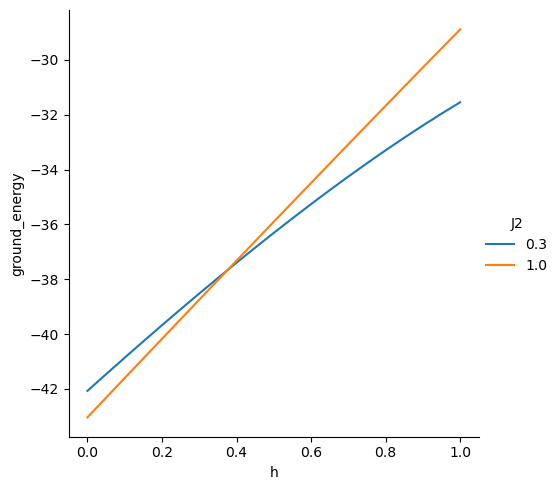

In [7]:
sns.relplot(
    pd.DataFrame(outputs).astype({"J2": str}),
    x="h",
    y="ground_energy",
    hue="J2",
    kind="line",
)

In [6]:
spin_system(
    heisenberg_transversal_field(lattice, J2=0.3, h=0),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
).ground_energy

2024-09-27 16:20:19.740 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


-42.07430858877421

In [7]:
J2 = 0.8

In [8]:
gs = np.zeros(2**lattice.number_spins)
system = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
# gs[system.basis.states] = system.ground_state

In [9]:
system.get_eigenstates(2)

2024-09-27 16:20:20.185 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 2.


(array([-40.63622411, -40.51834201]),
 array([[-4.60058596e-17,  1.76833790e-17],
        [-2.25457090e-17,  9.97852621e-18],
        [-2.26436508e-17,  1.23441068e-17],
        ...,
        [-1.29392732e-17,  3.78279772e-18],
        [-1.57242797e-17,  5.54081108e-18],
        [-1.06944149e-16,  2.87880069e-17]]))

In [83]:
transformed = hadamard_transform(gs)

2024-09-25 20:45:31.659 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-25 20:45:31.719 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-25 20:45:31.882 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-25 20:45:31.986 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-25 20:45:32.063 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-25 20:45:32.131 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-25 20:45:32.195 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-25 20:45:32.269 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-25 20:45:32.341 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-09-25 20:45:32.410 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 10.0 of 24.0
2024-09-25 20:45:32.472 | DEBUG    | misc_utils:h

In [84]:
gs @ transformed / np.linalg.norm(gs) / np.linalg.norm(transformed)

0.37499999999999994

In [77]:
system_nosym = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
states = system_nosym.basis.states
gs_nosym = system_nosym.get_ground_state_coeffs(states, apply_symmetries=False)
gs_sym = system.get_ground_state_coeffs(states, apply_symmetries=True)

2024-09-25 20:41:25.419 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


IndexError: index 0 is out of bounds for axis 0 with size 0

In [46]:
J2 = 0.3
system = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
eps_train = 1e-2
evaluate_hadamard_learning_test_set(
    wavefunction=system.ground_state,
    basis=system.basis,
    sample_power=sample_power,
    test_size=50000,
    eps_train=eps_train,
)

2024-09-25 20:26:51.799 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


{'sample_size': 157048,
 'eps_train': 0.01,
 'sample_power': 2,
 'test_size': 50000,
 'accuracy_test': 0.48851,
 'sign_overlap_test': -0.339729668276139}

In [30]:
system_heisenberg = spin_system(
    heisenberg(lattice, J2=0.4),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)

In [31]:
transformed = hadamard_transform(system_heisenberg.ground_state)
system_heisenberg.ground_state @ transformed / np.linalg.norm(
    transformed
) / np.linalg.norm(system_heisenberg.ground_state)

2024-09-25 20:09:57.487 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2024-09-25 20:12:04.871 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -40.7607708401
2024-09-25 20:12:04.873 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-25 20:12:04.931 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-25 20:12:05.097 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-25 20:12:05.201 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-25 20:12:05.277 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-25 20:12:05.344 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-25 20:12:05.408 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-25 20:12:05.482 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-25 20:12:05.

0.029003381426328516

In [21]:
J2 = 1
h = 0.2
system = spin_system(
    heisenberg_transversal_field(lattice, J2=J2, h=h),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
print(system.ground_state)
system.ground_energy

2024-09-27 16:23:58.290 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


[-2.89880804e-18 -7.03745411e-20 -1.39773323e-18 ... -1.13316690e-18
 -2.22750916e-18  7.10178809e-18]


-43.039588992336355

In [17]:
np.linspace(0, 1, 21)[8] == 0.4

True

In [31]:
J2 = 1
h = 0.41
system = spin_system(
    heisenberg_transversal_field(lattice, J2=J2, h=h),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
print(system.ground_state)
system.ground_energy

hadamard_transform(system.ground_state) @ system.ground_state

2024-09-27 16:28:36.416 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2024-09-27 16:33:01.941 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -43.0395889923
2024-09-27 16:33:01.944 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-27 16:33:02.023 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0


[-4.44875740e-18 -2.66609116e-20 -2.12685215e-18 ... -3.52590996e-18
  9.06746242e-19 -4.01949460e-18]


2024-09-27 16:33:02.204 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-27 16:33:02.329 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-27 16:33:02.434 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-27 16:33:02.528 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-27 16:33:02.623 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-27 16:33:02.731 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-27 16:33:02.830 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-09-27 16:33:02.920 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 10.0 of 24.0
2024-09-27 16:33:03.005 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 11.0 of 24.0
2024-09-27 16:33:03.086 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 12.0 of 24.0
2024-09-27 16:33:03.161 | DEBUG    | misc_utils

1.000000000000002

In [28]:
pd.DataFrame(outputs).query("J2 == 1")

,sample_size,eps_train,sample_power,test_size,accuracy_test,sign_overlap_test,h,lattice,overlap_with_transformed,J2,ground_energy
1,24209,0.01,2,50000,0.61960,0.973182,0.00,kagome2x4,1.00,1.0,-43.039589
3,24209,0.01,2,50000,0.62102,0.974197,0.05,kagome2x4,1.00,1.0,-43.039589
5,24209,0.01,2,50000,0.61658,0.973675,0.10,kagome2x4,1.00,1.0,-43.039589
7,24209,0.01,2,50000,0.61704,0.972152,0.15,kagome2x4,1.00,1.0,-43.039589
9,24209,0.01,2,50000,0.61242,0.971423,0.20,kagome2x4,1.00,1.0,-43.039589
11,24209,0.01,2,50000,0.62288,0.974959,0.25,kagome2x4,1.00,1.0,-43.039589
13,24209,0.01,2,50000,0.61992,0.973691,0.30,kagome2x4,1.00,1.0,-43.039589
15,24209,0.01,2,50000,0.61656,0.973834,0.35,kagome2x4,1.00,1.0,-43.039589
17,24209,0.01,2,50000,0.61630,0.974135,0.40,kagome2x4,1.00,1.0,-43.039589
19,24209,0.01,2,50000,0.62028,0.974699,0.45,kagome2x4,1.00,1.0,-43.039589


In [1]:
pd.DataFrame(outputs).query("J2 == 1.0")

NameError: name 'pd' is not defined

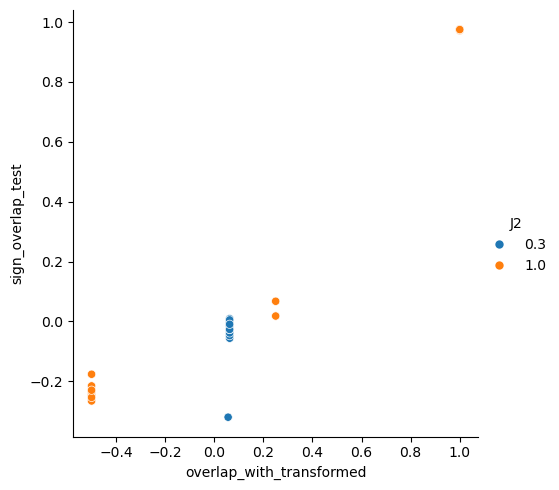

In [6]:
sns.relplot(
    pd.DataFrame(outputs).astype({"J2": str}),
    x="overlap_with_transformed",
    y="sign_overlap_test",
    hue="J2",
    #  kind="line",
)